In [108]:
# Cell 1: Cài YOLOv8 và kiểm tra môi trường

!pip install -U ultralytics --quiet

import torch, os, sys
from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Không thấy GPU, nhớ bật CUDA / chọn đúng kernel nhé")


PyTorch: 2.9.1+cu128
CUDA available: True
GPU name: Quadro RTX 5000


In [109]:
# Cell 1: Import & config basic

import os
from pathlib import Path
import math
from typing import List, Tuple

import torch
import torch.nn.functional as F
from torchvision import transforms

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Dùng tqdm cho progress
from tqdm.auto import tqdm

# ===== CẤU HÌNH ĐƯỜNG DẪN =====
ROOT_DIR = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images")
TRAIN_DIR = ROOT_DIR / "Train"

# Ảnh có nhiều món ăn để test segmentation
TEST_IMAGE = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/demo/multi_food.jpg")  # chỉnh lại cho đúng

# Check
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_IMAGE:", TEST_IMAGE)

# ===== DEVICE =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Add project root ---
import sys
from pathlib import Path

ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("✓ Added to sys.path:", ROOT)


TRAIN_DIR: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Train
TEST_IMAGE: /media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/demo/multi_food.jpg
Device: cuda
✓ Added to sys.path: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam


In [110]:
# Cell 2: Đọc class_names từ thư mục con trong Train

class_names = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
num_classes = len(class_names)

print("Số lớp:", num_classes)
for i, c in enumerate(class_names):
    print(f"{i:2d} - {c}")


Số lớp: 33
 0 - Banh beo
 1 - Banh bot loc
 2 - Banh can
 3 - Banh canh
 4 - Banh chung
 5 - Banh cuon
 6 - Banh duc
 7 - Banh gio
 8 - Banh khot
 9 - Banh mi
10 - Banh pia
11 - Banh tet
12 - Banh trang nuong
13 - Banh xeo
14 - Bun bo Hue
15 - Bun dau mam tom
16 - Bun mam
17 - Bun rieu
18 - Bun thit nuong
19 - Ca kho to
20 - Canh chua
21 - Cao lau
22 - Chao long
23 - Com tam
24 - Goi cuon
25 - Hu tieu
26 - Mi quang
27 - Nem chua
28 - Pho
29 - Xoi xeo
30 - banh_da_lon
31 - banh_tieu
32 - banh_trung_thu


In [111]:
# --- Add project root ---
import sys
from pathlib import Path

ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("✓ Added to sys.path:", ROOT)

# --- Import model from /model/ ---
from model.mtl_efficientnet_b0 import MTLEfficientNetB0

# Load model
num_classes = 33
device = "cuda"

model = MTLEfficientNetB0(num_classes=num_classes)
model.to(device)

print("✓ Model initialized")





✓ Added to sys.path: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam
✓ Model initialized


In [112]:
# Cell 1: Import & cấu hình đường dẫn project

import sys
from pathlib import Path

import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ĐƯỜNG DẪN GỐC PROJECT (chỉnh lại nếu khác)
ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")

# Thêm ROOT vào sys.path để import được module trong /model
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("✅ ROOT =", ROOT)
print("✅ sys.path đã thêm:", ROOT in map(Path, sys.path))


✅ ROOT = /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam
✅ sys.path đã thêm: True


In [113]:
# Cell 2: Import MTLEfficientNetB0 + đọc label

from model.mtl_efficientnet_b0 import MTLEfficientNetB0

# Nếu anh có file label.txt thì đọc từ đó cho chắc
label_path = ROOT / "label.txt"

if label_path.exists():
    with open(label_path, "r", encoding="utf-8") as f:
        CLASS_NAMES = [line.strip() for line in f if line.strip()]
    print(f"✅ Đã load {len(CLASS_NAMES)} label từ", label_path)
else:
    # Fallback: tự gõ tay (hoặc copy list cũ)
    CLASS_NAMES = [
        "Banh beo","Banh bot loc","Banh can","Banh canh","Banh chung",
        "Banh cuon","Banh duc","Banh gio","Banh khot","Banh mi","Banh pia",
        "Banh tet","Banh trang nuong","Banh xeo","Bun bo Hue","Bun dau mam tom",
        "Bun mam","Bun rieu","Bun thit nuong","Ca kho to","Canh chua","Cao lau",
        "Chao long","Com tam","Goi cuon","Hu tieu","Mi quang","Nem chua","Pho",
        "Xoi xeo","banh_da_lon","banh_tieu","banh_trung_thu",
    ]
    print("⚠️ Không tìm thấy label.txt, dùng list CLASS_NAMES mặc định.")
    
num_classes = len(CLASS_NAMES)
print("Số lớp:", num_classes)


⚠️ Không tìm thấy label.txt, dùng list CLASS_NAMES mặc định.
Số lớp: 33


In [114]:
# Cell 3: Load model EfficientNet + checkpoint mới nhất

import sys
from pathlib import Path
import torch

# 1) Lấy project root
ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("✅ Added to sys.path:", ROOT)

# 2) Import model từ folder /model
from model.mtl_efficientnet_b0 import MTLEfficientNetB0

# 3) Khởi tạo model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 33
model = MTLEfficientNetB0(num_classes=num_classes)
model.to(device)

print("Thiết bị:", device)

# 4) Tìm checkpoint mtl_efficientnet_b0_best.pt trong các folder con của /Jupyter/runs
runs_dir = ROOT / "Jupyter" / "runs"
print("📁 runs_dir:", runs_dir)

# lấy tất cả file *best.pt
ckpt_list = sorted(runs_dir.rglob("*best.pt"))
print("\n🔍 Found checkpoints:")
for p in ckpt_list:
    print("  -", p)

if not ckpt_list:
    raise FileNotFoundError("❌ Không tìm thấy bất kỳ file '*best.pt' nào trong thư mục 'runs/'")

# => Lấy file checkpoint mới nhất
CKPT_PATH = ckpt_list[-1]
print("\n✅ Using checkpoint:", CKPT_PATH)

# 5) Load weight
ckpt = torch.load(CKPT_PATH, map_location=device)

# ---- CHỖ QUAN TRỌNG: bóc đúng state_dict của model ----
if "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    # Trường hợp bạn save thẳng model.state_dict(...)
    state_dict = ckpt

# Nếu trong state_dict có prefix kiểu "model." thì bỏ đi
from collections import OrderedDict
clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_k = k
    if new_k.startswith("model."):
        new_k = new_k[len("model."):]
    clean_state_dict[new_k] = v

# Load vào model (strict=False để bỏ qua key thừa/thiếu nhẹ)
missing, unexpected = model.load_state_dict(clean_state_dict, strict=False)

print("\n🔁 load_state_dict done.")
print("   Missing keys:", missing)
print("   Unexpected keys:", unexpected)

model.eval()
print("\n✅ Model loaded & set to eval().")


✅ Added to sys.path: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam


Thiết bị: cuda
📁 runs_dir: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs

🔍 Found checkpoints:
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_01/checkpoints/mtl_effcientnet_b0_best.pt
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-101729/checkpoints/mtl_effcientnet_b0_best.pt

✅ Using checkpoint: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-101729/checkpoints/mtl_effcientnet_b0_best.pt

🔁 load_state_dict done.
   Missing keys: ['backbone.features.0.0.weight', 'backbone.features.0.1.weight', 'backbone.features.0.1.bias', 'backbone.features.0.1.running_mean', 'backbone.features.0.1.running_var', 'backbone.features.1.0.block.0.0.weight', 'backbone.features.1.0.block.0.1.weight', 'backbone.features.1.0.block.0.1.bias', 'backbone.features.1.0.block.0.1.running_mean', 'backbone.features.1.0.block.0.1.running_var', 'backbo

In [115]:
# Cell 4: Load CLASS_NAMES từ label.txt (nếu có)

from pathlib import Path

label_path = ROOT / "model" / "label.txt"
CLASS_NAMES = []

if label_path.exists():
    with open(label_path, "r", encoding="utf-8") as f:
        CLASS_NAMES = [ln.strip() for ln in f if ln.strip()]
    print(f"✅ Đã đọc {len(CLASS_NAMES)} lớp từ", label_path)
else:
    # Fallback: nếu không có label.txt thì dùng list cứng (tùy bạn)
    CLASS_NAMES = [
        "Banh beo", "Banh bot loc", "Banh canh", "Banh chung",
        "Banh cuon", "Banh gio", "Banh khot", "Banh mi",
        "Banh pia", "Banh tet", "Banh trang nuong", "Banh xeo",
        "Bun bo Hue", "Bun dau mam tom", "Bun mam", "Bun rieu",
        "Bun thit nuong", "Ca kho to", "Canh chua", "Cao lau",
        "Chao long", "Com tam", "Goi cuon", "Hu tieu",
        "Mi quang", "Nem chua", "Pho", "Xoi xeo",
        "banh_da_lon", "banh_tieu", "banh_trung_thu",
        # Thêm nếu thiếu…
    ]
    print("⚠️ Không thấy label.txt, đang dùng CLASS_NAMES mặc định.")

num_classes = len(CLASS_NAMES)
print("Số lớp:", num_classes)


✅ Đã đọc 33 lớp từ /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/model/label.txt
Số lớp: 33


In [116]:
# Cell 5: Chuẩn hóa ảnh & hàm predict cho từng patch

import torch
from torchvision import transforms as T
from PIL import Image
import numpy as np

# Thông số tiền xử lý – nên khớp với lúc train
IMG_SIZE = 224  # nếu lúc train bạn dùng 256 thì đổi lại
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

@torch.no_grad()
def predict_patch(pil_img_patch, topk=1):
    """
    Nhận vào 1 patch dạng PIL.Image (RGB),
    trả về: (class_idx, class_name, prob)
    """
    model.eval()
    x = transform_eval(pil_img_patch).unsqueeze(0).to(device)  # (1,3,H,W)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0]

    top_prob, top_idx = torch.max(probs, dim=0)
    top_prob = top_prob.item()
    top_idx = top_idx.item()

    class_name = CLASS_NAMES[top_idx] if 0 <= top_idx < len(CLASS_NAMES) else f"cls_{top_idx}"
    return top_idx, class_name, top_prob


In [117]:
# Cell 6: Chia ảnh thành lưới & dự đoán trên từng ô (bản có debug)

import math

def slide_over_image(
    pil_img,
    grid_rows=3,
    grid_cols=3,
    conf_thres=0.8,
    keep_all=False,      # NEW: nếu True thì không lọc theo threshold
    verbose=True
):
    """
    Chia ảnh thành grid_rows x grid_cols ô, predict trên từng ô.
    Trả về detections = list các dict:
        {
          "box": (x1, y1, x2, y2),
          "cls_idx": int,
          "cls_name": str,
          "prob": float
        }
    """
    W, H = pil_img.size
    cell_w = W // grid_cols
    cell_h = H // grid_rows

    detections = []

    print(f"Ảnh gốc: {W}x{H}, grid = {grid_rows}x{grid_cols}")
    if verbose:
        print("===== Kết quả từng ô =====")

    for r in range(grid_rows):
        for c in range(grid_cols):
            x1 = c * cell_w
            y1 = r * cell_h
            x2 = W if c == grid_cols - 1 else (c + 1) * cell_w
            y2 = H if r == grid_rows - 1 else (r + 1) * cell_h

            patch = pil_img.crop((x1, y1, x2, y2))

            cls_idx, cls_name, prob = predict_patch(patch)

            if verbose:
                print(f"[r={r}, c={c}] -> {cls_name:20s} | prob={prob:.3f}")

            if keep_all or prob >= conf_thres:
                detections.append({
                    "box": (x1, y1, x2, y2),
                    "cls_idx": cls_idx,
                    "cls_name": cls_name,
                    "prob": prob
                })

    if verbose:
        print("========================")
        print("Tổng số ô được giữ lại:", len(detections),
              "(keep_all =", keep_all, ", conf_thres =", conf_thres, ")")
    return detections


In [118]:
# Cell 7: Vẽ bounding box & nhãn lên ảnh gốc

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_detections(pil_img, detections, figsize=(10, 8)):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(pil_img)
    ax.axis("off")

    for det in detections:
        x1, y1, x2, y2 = det["box"]
        cls_name = det["cls_name"]
        prob = det["prob"]

        w = x2 - x1
        h = y2 - y1

        # Vẽ khung
        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)

        # Vẽ nhãn ở trên
        ax.text(
            x1, y1 - 5,
            f"{cls_name} ({prob:.2f})",
            fontsize=10,
            color="black",
            bbox=dict(facecolor="yellow", alpha=0.7, edgecolor="none")
        )

    plt.tight_layout()
    plt.show()


Image: 1.webp
Ảnh gốc: 589x389, grid = 3x3
===== Kết quả từng ô =====
[r=0, c=0] -> 29: Xoi xeo          | prob=0.035
[r=0, c=1] -> 28: Pho              | prob=0.036
[r=0, c=2] -> 28: Pho              | prob=0.035
[r=1, c=0] -> 19: Ca kho to        | prob=0.038
[r=1, c=1] -> 18: Bun thit nuong   | prob=0.034
[r=1, c=2] -> 19: Ca kho to        | prob=0.035
[r=2, c=0] -> 12: Banh trang nuong | prob=0.034
[r=2, c=1] -> 19: Ca kho to        | prob=0.036
[r=2, c=2] -> 4: Banh chung        | prob=0.037
Tổng số ô được giữ lại: 9 (keep_all = True , conf_thres = 0.8 )


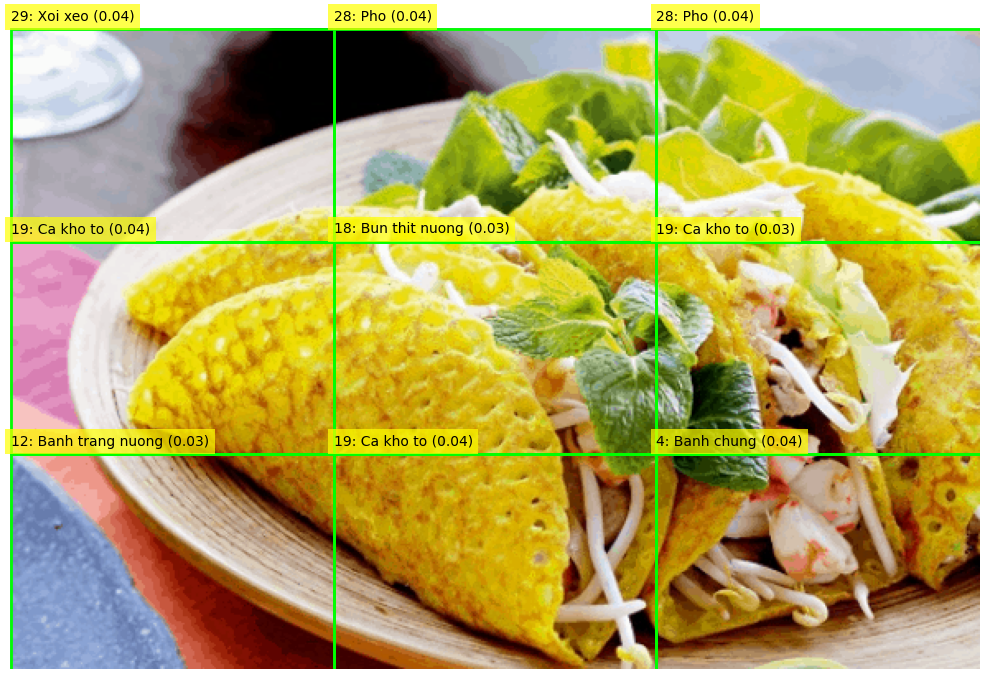

In [122]:

# Cell 8: Test trên 1 ảnh có nhiều món ăn

from pathlib import Path
from PIL import Image

# TODO: Đổi sang ảnh có món ăn nằm trong 33 lớp để test chuẩn
IMG_PATH = "1.webp"#ROOT / "images" / "multi_food_example.jpg"

print("Image:", IMG_PATH)
pil_img = Image.open(IMG_PATH).convert("RGB")

# Gợi ý: bắt đầu với grid 3x3, threshold thấp để xem behaviour
detections = slide_over_image(
    pil_img,
    grid_rows=3,
    grid_cols=3,
    conf_thres=0.8,   # hạ xuống 0.5 hoặc 0.3
    keep_all=True,   # nếu muốn xem hết thì bật True
    verbose=True
)

visualize_detections(pil_img, detections)



In [11]:
# Cell 3: Load model EfficientNet + checkpoint mới nhất

import sys
from pathlib import Path
import torch

# 1) Lấy project root
ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("✅ Added to sys.path:", ROOT)

# 2) Import model từ folder /model
from model.mtl_efficientnet_b0 import MTLEfficientNetB0

# 3) Khởi tạo model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 33
model = MTLEfficientNetB0(num_classes=num_classes)
model.to(device)

print("Thiết bị:", device)

# 4) Tìm checkpoint mtl_efficientnet_b0_best.pt trong các folder con của /Jupyter/runs
runs_dir = ROOT / "Jupyter" / "runs"
print("📁 runs_dir:", runs_dir)

# lấy tất cả file *best.pt
ckpt_list = sorted(runs_dir.rglob("*best.pt"))
print("\n🔍 Found checkpoints:")
for p in ckpt_list:
    print("  -", p)

if not ckpt_list:
    raise FileNotFoundError("❌ Không tìm thấy bất kỳ file '*best.pt' nào trong thư mục 'runs/'")

# => Lấy file checkpoint mới nhất
CKPT_PATH = ckpt_list[-1]
print("\n✅ Using checkpoint:", CKPT_PATH)

# 5) Load weight
ckpt = torch.load(CKPT_PATH, map_location=device)

# ---- CHỖ QUAN TRỌNG: bóc đúng state_dict của model ----
if "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    # Trường hợp bạn save thẳng model.state_dict(...)
    state_dict = ckpt

# Nếu trong state_dict có prefix kiểu "model." thì bỏ đi
from collections import OrderedDict
clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_k = k
    if new_k.startswith("model."):
        new_k = new_k[len("model."):]
    clean_state_dict[new_k] = v

# Load vào model (strict=False để bỏ qua key thừa/thiếu nhẹ)
missing, unexpected = model.load_state_dict(clean_state_dict, strict=False)

print("\n🔁 load_state_dict done.")
print("   Missing keys:", missing)
print("   Unexpected keys:", unexpected)

model.eval()
print("\n✅ Model loaded & set to eval().")


✅ Added to sys.path: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam
Thiết bị: cuda
📁 runs_dir: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs

🔍 Found checkpoints:
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_01/checkpoints/mtl_effcientnet_b0_best.pt
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-101729/checkpoints/mtl_effcientnet_b0_best.pt
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-181112/checkpoints/mtl_effcientnet_b0_best.pt

✅ Using checkpoint: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-181112/checkpoints/mtl_effcientnet_b0_best.pt

🔁 load_state_dict done.
   Missing keys: ['backbone.features.0.0.weight', 'backbone.features.0.1.weight', 'backbone.features.0.1.bias', 'backbone.features.0.1.running_mean', 'backbone.features.0.1.running_var', 'ba

In [13]:
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

patch_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

UNKNOWN_LABEL = "Không rõ món gì"
UNKNOWN_THRES = 0.60

def predict_patch_with_unknown(pil_patch):
    model.eval()
    with torch.no_grad():
        x = patch_transform(pil_patch).unsqueeze(0).to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0]
        prob, idx = torch.max(probs, dim=0)
        prob = prob.item()
        idx = idx.item()

    if prob < UNKNOWN_THRES:
        return None, UNKNOWN_LABEL, prob
    else:
        return idx, CLASS_NAMES[idx], prob


In [14]:
detections = detect_foods_on_table(
    pil_img,
    grid_rows=4,
    grid_cols=4,
    conf_thres=0.5,
    verbose=True
)


Ảnh bàn ăn: 1920x1280, grid = 4x4
===== Kết quả từng ô =====
[r=0, c=0] -> Không rõ món gì      | prob=0.037
[r=0, c=1] -> Không rõ món gì      | prob=0.036
[r=0, c=2] -> Không rõ món gì      | prob=0.037
[r=0, c=3] -> Không rõ món gì      | prob=0.035
[r=1, c=0] -> Không rõ món gì      | prob=0.039
[r=1, c=1] -> Không rõ món gì      | prob=0.036
[r=1, c=2] -> Không rõ món gì      | prob=0.038
[r=1, c=3] -> Không rõ món gì      | prob=0.037
[r=2, c=0] -> Không rõ món gì      | prob=0.038
[r=2, c=1] -> Không rõ món gì      | prob=0.037
[r=2, c=2] -> Không rõ món gì      | prob=0.038
[r=2, c=3] -> Không rõ món gì      | prob=0.038
[r=3, c=0] -> Không rõ món gì      | prob=0.037
[r=3, c=1] -> Không rõ món gì      | prob=0.039
[r=3, c=2] -> Không rõ món gì      | prob=0.035
[r=3, c=3] -> Không rõ món gì      | prob=0.036
Tổng số ô giữ lại: 16


In [15]:
# Cell 4: Thống kê số lượng mỗi món trên bàn

from collections import Counter

def summarize_table(detections):
    # Đếm theo tên cls_name
    names = [det["cls_name"] for det in detections]
    counter = Counter(names)

    print("Tóm tắt món trên bàn:")
    for name, cnt in counter.items():
        print(f"- {name}: {cnt} ô")

    return counter


Ảnh: /home/mtl/Downloads/am-thuc-Bac-bo.webp
Ảnh bàn ăn: 1920x1280, grid = 4x4
===== Kết quả từng ô =====
[r=0, c=0] -> Không rõ món gì      | prob=0.037
[r=0, c=1] -> Không rõ món gì      | prob=0.036
[r=0, c=2] -> Không rõ món gì      | prob=0.037
[r=0, c=3] -> Không rõ món gì      | prob=0.035
[r=1, c=0] -> Không rõ món gì      | prob=0.039
[r=1, c=1] -> Không rõ món gì      | prob=0.036
[r=1, c=2] -> Không rõ món gì      | prob=0.038
[r=1, c=3] -> Không rõ món gì      | prob=0.037
[r=2, c=0] -> Không rõ món gì      | prob=0.038
[r=2, c=1] -> Không rõ món gì      | prob=0.037
[r=2, c=2] -> Không rõ món gì      | prob=0.038
[r=2, c=3] -> Không rõ món gì      | prob=0.038
[r=3, c=0] -> Không rõ món gì      | prob=0.037
[r=3, c=1] -> Không rõ món gì      | prob=0.039
[r=3, c=2] -> Không rõ món gì      | prob=0.035
[r=3, c=3] -> Không rõ món gì      | prob=0.036
Tổng số ô giữ lại: 16
Tóm tắt món trên bàn:
- Không rõ món gì: 16 ô


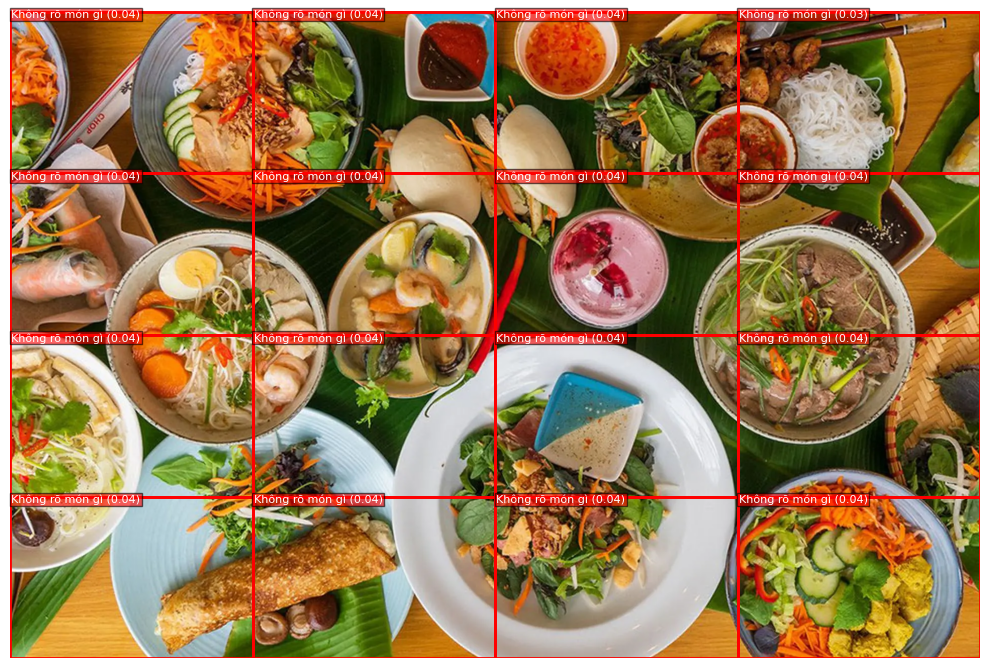

In [22]:
from pathlib import Path
from PIL import Image

IMG_PATH = "/home/mtl/Downloads/am-thuc-Bac-bo.webp"   # sửa lại tên file

print("Ảnh:", IMG_PATH)
pil_img = Image.open(IMG_PATH).convert("RGB")


detections = detect_foods_on_table(
    pil_img,
    grid_rows=4,
    grid_cols=4,
    conf_thres=0.3,
    verbose=True
)

summarize_table(detections)
visualize_table_detections(pil_img, detections)
